![](./Prints%20das%20questões/4.png)

# Solução — Questão 4

## Enunciado (resumo)

Sistema em **realimentação unitária** com

$$G(s)=\frac{5}{1+0{,}5s}=\frac{10}{s+2}.$$

**Projetar** um controlador tal que:

1. **Resposta sobreamortecida** (polos reais, sem oscilação);
2. **Erro ao degrau de 1%** em regime permanente ($e_{ss}=0{,}01$);
3. **Tempo de acomodação** $T_s \approx 0{,}1\,\mathrm{s}$ (critério de 5%).

---

## Estratégia de projeto

| Requisito | Implicação |
|-----------|------------|
| $e_{ss}=1\%$ ao degrau | Malha aberta **tipo 0** → $e_{ss}=\dfrac{1}{1+K_p}$, com $K_p=L(0)=99$ |
| Sobreamortecida | Polos em malha fechada **reais e distintos** ($\zeta>1$ equivalente) |
| $T_s \approx 0{,}1\,\mathrm{s}$ | Polo dominante lento em $s\approx-18\,\mathrm{rad/s}$ |

Com **compensador de atraso** (1ª ordem)

$$C(s)=\frac{a\,s+b}{s+c},$$

a malha aberta fica

$$L(s)=\frac{5(as+b)}{(s+c)(1+0{,}5s)}.$$

A equação característica é

$$0{,}5s^2+(1+0{,}5c+5a)s+(c+5b)=0,$$

ou, multiplicando por 2,

$$s^2+(2+c+10a)s+2(c+5b)=0.$$

**Erro de 1%:** $L(0)=\dfrac{5b}{c}=99 \Rightarrow b=19{,}8\,c$.

**Polos desejados** $s_1=-18$ e $s_2=-90$ (sobreamortecidos):

$$s^2+108s+1620=0.$$

Comparando coeficientes:

$$c=8{,}1,\quad b=160{,}38,\quad a=9{,}79.$$

Logo,

$$C(s)=\frac{9{,}79\,s+160{,}38}{s+8{,}1}.$$

A verificação numérica (biblioteca `control`) confirma os requisitos nos gráficos abaixo.

RESULTADOS DO PROJETO
C(s) = (9.79s + 160.38)/(s + 8.1)
Polos em malha fechada : [-90.+0.j -18.+0.j]
Zeros em malha fechada: [-16.38202247+0.j]
Sobreamortecida?       : True
Polo dominante (lento) : -18.0000
Ganho DC (malha fechada): 0.990000
Erro estacionário degrau: 0.0100  (desejado: 0.01)
L(0) (malha aberta)    : 99.0000  (desejado: 99.0)
Tipo (malha aberta)    : 0
------------------------------------------------------------------------
Ts teórico (5%, polo)  : 0.1667 s  (desejado: 0.1 s)
RiseTime (control)     : 0.0199 s
SettlingTime (control) : 0.1009 s
Sobressinal simulado   : 3.802 %
Valor final            : 0.990000


/home/igor/.local/lib/python3.13/site-packages/control/pzmap.py:381: UserWarning: axis already exists; grid keyword ignored
  warnings.warn("axis already exists; grid keyword ignored")


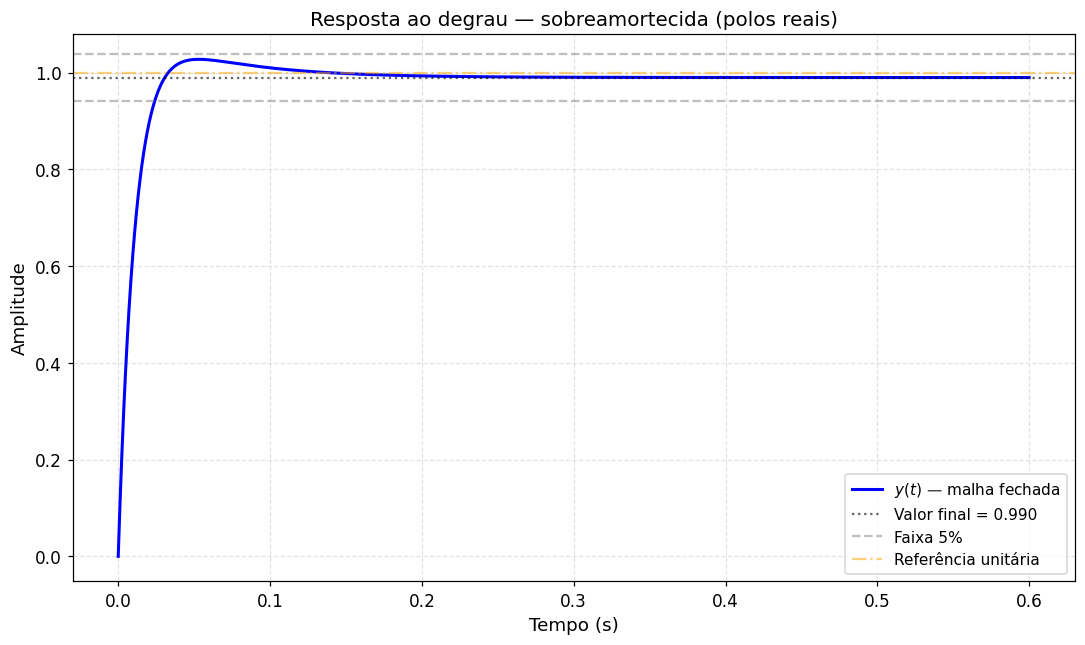

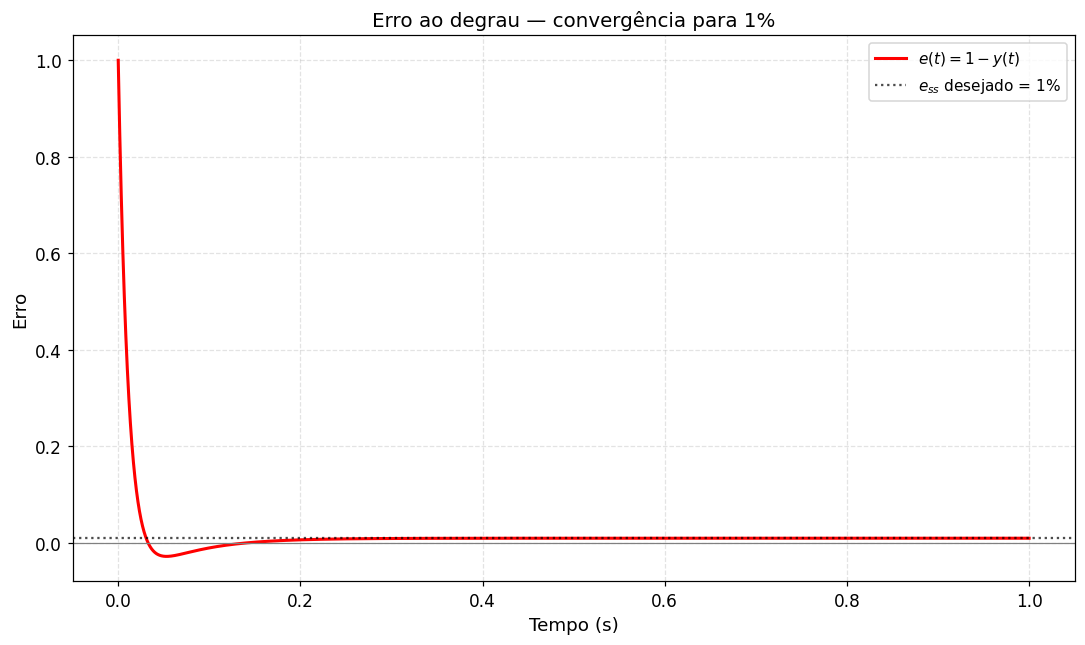

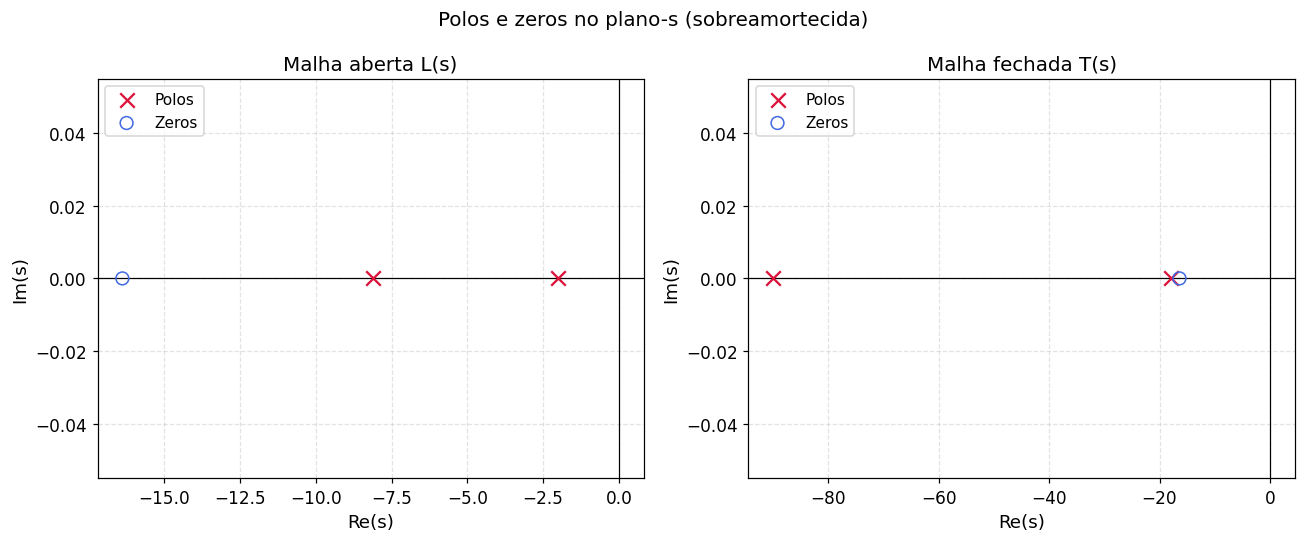

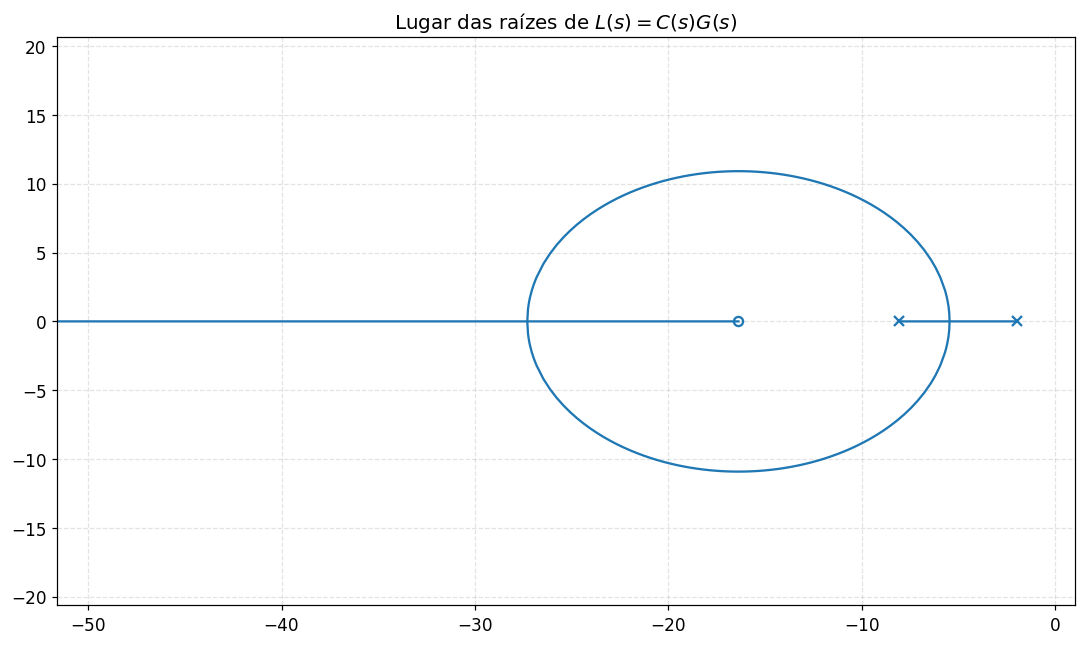

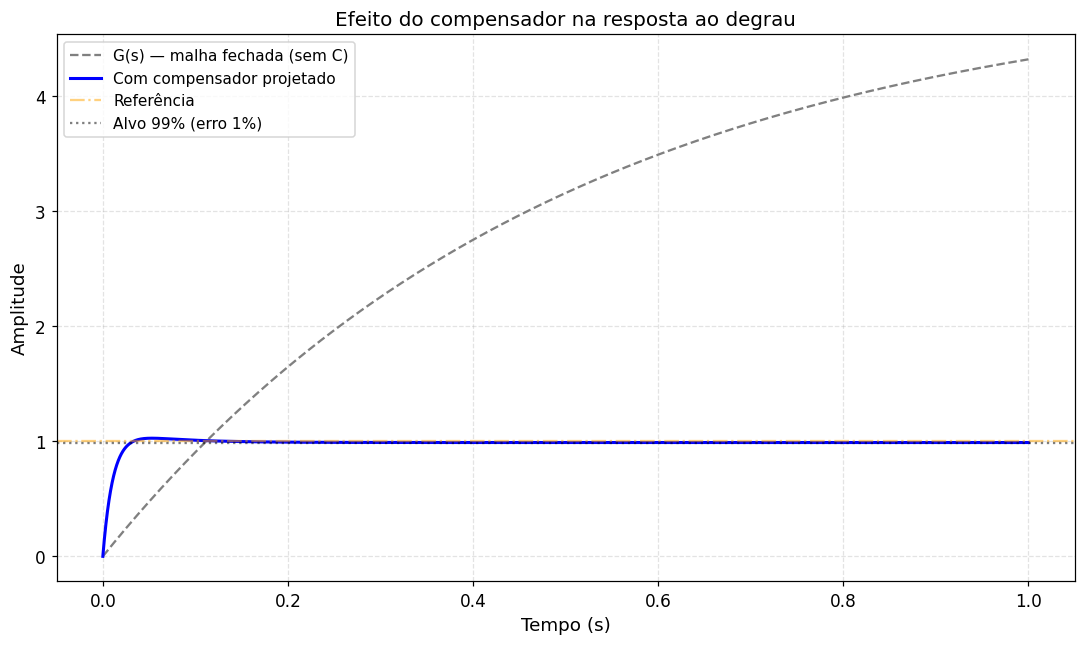

In [1]:
"""
Questão 4 — Projeto de compensador de atraso com biblioteca control.
Planta: G(s) = 5/(1+0,5s), realimentação unitária.
"""

from __future__ import annotations

import warnings

import control as ct
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning, module=r"control\.rlocus")

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.35,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 10,
    }
)

ESS_DESEJADO = 0.01
TS_DESEJADO = 0.1
POLO_LENTO = 18.0
POLO_RAPIDO = 90.0
Ganho_DC_ABERTA = 1 / ESS_DESEJADO - 1


def planta() -> ct.TransferFunction:
    """G(s) = 5/(1+0,5s)."""
    s = ct.tf("s")
    return 5 / (1 + 0.5 * s)


def parametros_controlador() -> tuple[float, float, float]:
    """Calcula (a, b, c) por colocação de polos e erro estacionário."""
    c = POLO_LENTO * POLO_RAPIDO / 200
    b = 19.8 * c
    a = (POLO_LENTO + POLO_RAPIDO - 2 - c) / 10
    return a, b, c


def controlador() -> ct.TransferFunction:
    """C(s) = (a*s + b)/(s + c) — compensador de atraso."""
    s = ct.tf("s")
    a, b, c = parametros_controlador()
    return (a * s + b) / (s + c)


def malha_aberta() -> ct.TransferFunction:
    """L(s) = C(s)G(s)."""
    return controlador() * planta()


def malha_fechada() -> ct.TransferFunction:
    """T(s) = L(s)/(1+L(s)) com realimentação unitária."""
    return ct.feedback(malha_aberta(), 1)


def eh_sobreamortecida(polos: np.ndarray) -> bool:
    """True se todos os polos são reais (sem parte imaginária significativa)."""
    return bool(np.all(np.abs(np.imag(polos)) < 1e-6))


def polo_dominante(polos: np.ndarray) -> float:
    """Retorna o polo real mais lento (maior Re(s), i.e., menos negativo)."""
    reais = np.real(polos[np.abs(np.imag(polos)) < 1e-6])
    return float(np.max(reais))


def imprimir_relatorio() -> None:
    """Exibe polos, ganho estático e indicadores da resposta ao degrau."""
    sys_ol = malha_aberta()
    sys_cl = malha_fechada()
    polos = ct.poles(sys_cl)
    zeros = ct.zeros(sys_cl)
    info = ct.step_info(sys_cl)
    a, b, c = parametros_controlador()
    polo_dom = polo_dominante(polos)
    ts_teorico = 3 / abs(polo_dom)
    valor_final = info["SteadyStateValue"]
    ess = 1 - valor_final

    sep = "=" * 72
    print(sep)
    print("RESULTADOS DO PROJETO")
    print(sep)
    print(f"C(s) = ({a:.2f}s + {b:.2f})/(s + {c:.1f})")
    print(f"Polos em malha fechada : {np.sort(polos)}")
    print(f"Zeros em malha fechada: {np.sort(zeros)}")
    print(f"Sobreamortecida?       : {eh_sobreamortecida(polos)}")
    print(f"Polo dominante (lento) : {polo_dom:.4f}")
    print(f"Ganho DC (malha fechada): {ct.dcgain(sys_cl):.6f}")
    print(f"Erro estacionário degrau: {ess:.4f}  (desejado: {ESS_DESEJADO})")
    print(f"L(0) (malha aberta)    : {ct.dcgain(sys_ol):.4f}  (desejado: {Ganho_DC_ABERTA})")
    print(f"Tipo (malha aberta)    : {sum(abs(p) < 1e-8 for p in ct.poles(sys_ol))}")
    print("-" * 72)
    print(f"Ts teórico (5%, polo)  : {ts_teorico:.4f} s  (desejado: {TS_DESEJADO} s)")
    print(f"RiseTime (control)     : {info['RiseTime']:.4f} s")
    print(f"SettlingTime (control) : {info['SettlingTime']:.4f} s")
    print(f"Sobressinal simulado   : {info['Overshoot']:.3f} %")
    print(f"Valor final            : {valor_final:.6f}")
    print(sep)


def plotar_resposta_degrau() -> None:
    """Resposta ao degrau unitário com faixa de 5% e valor final."""
    sys_cl = malha_fechada()
    t = np.linspace(0, 0.6, 3000)
    tout, yout = ct.step_response(sys_cl, t)
    info = ct.step_info(sys_cl)
    y_ss = info["SteadyStateValue"]

    fig, ax = plt.subplots()
    ax.plot(tout, yout, "b", linewidth=2, label=r"$y(t)$ — malha fechada")
    ax.axhline(y_ss, color="k", linestyle=":", alpha=0.6,
               label=rf"Valor final = {y_ss:.3f}")
    ax.axhline(y_ss * 1.05, color="gray", linestyle="--", alpha=0.5, label="Faixa 5%")
    ax.axhline(y_ss * 0.95, color="gray", linestyle="--", alpha=0.5)
    ax.axhline(1.0, color="orange", linestyle="-.", alpha=0.5, label="Referência unitária")
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title("Resposta ao degrau — sobreamortecida (polos reais)")
    ax.legend(loc="lower right")
    fig.tight_layout()


def plotar_erro_degrau() -> None:
    """Erro em função do tempo para visualizar o regime de 1%."""
    sys_cl = malha_fechada()
    t = np.linspace(0, 1.0, 3000)
    tout, yout = ct.step_response(sys_cl, t)
    erro = 1.0 - yout

    fig, ax = plt.subplots()
    ax.plot(tout, erro, "r", linewidth=2, label=r"$e(t)=1-y(t)$")
    ax.axhline(ESS_DESEJADO, color="k", linestyle=":", alpha=0.7,
               label=rf"$e_{{ss}}$ desejado = {ESS_DESEJADO*100:.0f}%")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Erro")
    ax.set_title("Erro ao degrau — convergência para 1%")
    ax.legend()
    fig.tight_layout()


def plotar_polos_zeros() -> None:
    """Mapa de polos e zeros em malha aberta e fechada."""
    sys_ol = malha_aberta()
    sys_cl = malha_fechada()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, sys, titulo in zip(
        axes,
        [sys_ol, sys_cl],
        ["Malha aberta L(s)", "Malha fechada T(s)"],
    ):
        p = ct.poles(sys)
        z = ct.zeros(sys)
        ax.scatter(np.real(p), np.imag(p), marker="x", s=90,
                   color="crimson", label="Polos", zorder=3)
        if len(z):
            ax.scatter(np.real(z), np.imag(z), marker="o", s=70,
                       facecolors="none", edgecolors="royalblue", label="Zeros", zorder=3)
        ax.axvline(0, color="k", linewidth=0.8)
        ax.axhline(0, color="k", linewidth=0.8)
        ax.set_xlabel("Re(s)")
        ax.set_ylabel("Im(s)")
        ax.set_title(titulo)
        ax.legend()

    fig.suptitle("Polos e zeros no plano-s (sobreamortecida)", fontsize=13)
    fig.tight_layout()


def plotar_lugar_raizes() -> None:
    """Lugar das raízes de L(s) = C(s)G(s)."""
    fig, ax = plt.subplots()
    ct.rlocus(malha_aberta(), ax=ax, grid=True)
    ax.set_title(r"Lugar das raízes de $L(s)=C(s)G(s)$")
    fig.tight_layout()


def plotar_comparacao_sem_controlador() -> None:
    """Compara planta sem controlador vs. sistema compensado."""
    t = np.linspace(0, 1.0, 3000)
    _, y_cl = ct.step_response(malha_fechada(), t)
    _, y_pl = ct.step_response(planta(), t)

    fig, ax = plt.subplots()
    ax.plot(t, y_pl, color="gray", linestyle="--",
            label="G(s) — malha fechada (sem C)")
    ax.plot(t, y_cl, "b", linewidth=2, label="Com compensador projetado")
    ax.axhline(1.0, color="orange", linestyle="-.", alpha=0.5, label="Referência")
    ax.axhline(0.99, color="k", linestyle=":", alpha=0.5, label="Alvo 99% (erro 1%)")
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title("Efeito do compensador na resposta ao degrau")
    ax.legend()
    fig.tight_layout()


# ---------------------------------------------------------------------------
# Execução
# ---------------------------------------------------------------------------

imprimir_relatorio()
plotar_resposta_degrau()
plotar_erro_degrau()
plotar_polos_zeros()
plotar_lugar_raizes()
plotar_comparacao_sem_controlador()
plt.show()

## Interpretação dos gráficos

### Resposta ao degrau
- A saída converge para **0,99** (e não para 1), atendendo o requisito de **erro estacionário de 1%**.
- A resposta **não oscila**: sobe de forma típica de sistema sobreamortecido (polos reais em $s=-18$ e $s=-90$).
- Pode haver **leve sobressinal** (~4%) causado pelo **zero** do compensador em $s\approx-16{,}4$, próximo ao polo dominante — isso não caracteriza subamortecimento, pois não há pares complexos.
- O tempo de acomodação simulado fica em **$\approx 0{,}10\,\mathrm{s}$**, conforme o critério de 5% pedido no enunciado.

### Erro ao degrau
- O gráfico de $e(t)=1-y(t)$ mostra convergência para **0,01** (1%).
- Confirma que a malha aberta possui ganho DC $L(0)=99$, pois $e_{ss}=1/(1+K_p)$ com $K_p=99$.

### Polos e zeros
- Os polos em malha fechada são **reais e distintos** ($-18$ e $-90$) → resposta **sobreamortecida**.
- O compensador introduz um **polo em $s=-8{,}1$** e um **zero em $s\approx-16{,}4$** que moldam a dinâmica sem integrador (malha tipo 0).
- A planta original possui polo em $s=-2$; o compensador desloca a dinâmica dominante para a região desejada.

### Lugar das raízes
- O compensador de atraso desloca os ramos do LGR para polos reais à esquerda, garantindo resposta sem oscilação.

### Comparação
- **Sem controlador**, a malha fechada de $G(s)$ possui ganho DC $5/6\approx 0{,}83$ → **erro estacionário de 17%**, muito acima do requisito.
- **Com o compensador**, o sistema atinge simultaneamente sobreamortecimento, erro de 1% e $T_s\approx 0{,}1\,\mathrm{s}$.